0 0.2732463777065277 0.9900000095367432
500 0.0004681878490373492 2.2606542110443115
1000 5.015046917833388e-05 2.3627142906188965
1500 3.903766628354788e-05 2.371016025543213
2000 0.00023114295618142933 2.3719332218170166
2500 2.9007009288761765e-05 2.376443862915039
3000 2.701863195397891e-05 2.376704692840576
3500 2.5787021513679065e-05 2.376431703567505
4000 2.6372526917839423e-05 2.373176097869873
4500 0.00012229912681505084 2.367661714553833
Learned lambda = 2.37731671333313


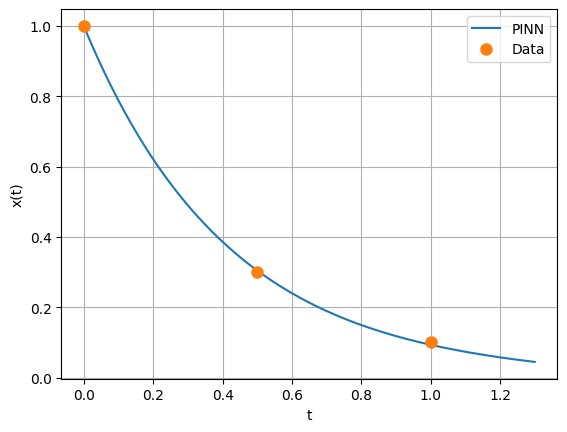

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --------------------------------------------------
# Neural network: t -> x(t)
# --------------------------------------------------
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.Tanh(),
    nn.Linear(10, 1)
)

# Unknown parameter lambda
lam = nn.Parameter(torch.tensor(1.0))

# Optimize both neural-network parameters and lambda
optimizer = torch.optim.Adam(
    list(model.parameters()) + [lam],
    lr=0.01
)

# --------------------------------------------------
# Collocation points for the differential equation
# --------------------------------------------------
t = torch.linspace(0, 1, 20).reshape(-1, 1)
t.requires_grad_(True)

# --------------------------------------------------
# Experimental data
# --------------------------------------------------
t_data = torch.tensor([[0.0],
                       [0.5],
                       [1.0]])

x_data = torch.tensor([[1.0],
                       [0.3],
                       [0.1]])

# --------------------------------------------------
# Training
# --------------------------------------------------
for epoch in range(5000):

    # PINN prediction at collocation points
    x = model(t)

    # Compute dx/dt using automatic differentiation
    x_t = torch.autograd.grad(
        x, t,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    # Physics loss: dx/dt + lambda*x = 0
    loss_physics = torch.mean((x_t + lam*x)**2)

    # Data loss
    x_pred = model(t_data)
    loss_data = torch.mean((x_pred - x_data)**2)

    # Total loss
    loss = loss_physics + loss_data

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(epoch, loss.item(), lam.item())

# --------------------------------------------------
# Final result
# --------------------------------------------------
print("Learned lambda =", lam.item())

# --------------------------------------------------
# Plot
# --------------------------------------------------
t_plot = torch.linspace(0, 1.3, 200).reshape(-1, 1)

with torch.no_grad():
    x_plot = model(t_plot)

plt.plot(t_plot.numpy(), x_plot.numpy(),
         label="PINN")

plt.plot(t_data.numpy(), x_data.numpy(),
         "o", markersize=8, label="Data")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()